# Expanded Exploratory Data Analysis
This notebook builds on the initial draft so commuters and planners can see both day-to-day signals and broader monthly trends in LIRR delays and Long Island weather.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")


## Load and normalize raw data
**Purpose:** bring both datasets into a consistent, analysis-ready shape.
**How to read it:** this cell standardizes column names, parses timestamps, and creates helper fields (date, weekday, month, depart hour) so later plots are comparable. If any of these derived fields look off, fix the parsing here before moving on.


In [33]:
weather_df = (
    pd.read_csv(
        '../data/raw/Long_Island_Weather.csv',
        parse_dates=['DATE'],
    )
    .rename(columns=str.strip)
    .sort_values('DATE')
)

lirr_df = (
    pd.read_csv(
        '../data/raw/MTA_LIRR_Delays__Beginning_2010_20260122.csv',
        dtype={
            'Train': 'string',
            'Branch': 'string',
            'Depart Station': 'string',
            'Arrive Station': 'string',
            'Period': 'string',
            'Status': 'string',
            'Delay Category': 'string',
            'Minutes Late': 'Float64',
        },
        parse_dates=['Service Date'],
        low_memory=False,
    )
    .rename(columns=str.strip)
)

lirr_df = lirr_df.assign(
    date=lambda df: df['Service Date'].dt.normalize(),
    weekday=lambda df: df['Service Date'].dt.day_name(),
    month=lambda df: df['Service Date'].dt.to_period('M'),
)
lirr_df['depart_ts'] = pd.to_datetime(lirr_df['Depart Time'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
lirr_df['depart_hour'] = lirr_df['depart_ts'].dt.hour
lirr_df['Delay Category'] = lirr_df['Delay Category'].fillna('Unknown')
lirr_df['is_late'] = lirr_df['Status'].fillna('').str.lower().eq('late')


## Raw data snapshots
**Purpose:** sanity-check the data sources and confirm key columns exist.
**How to read it:** you should see representative rows from each dataset and a quick count of records. If shapes are unexpectedly tiny or columns are missing, fix the file paths or parsing before continuing.


In [34]:
print(f'LIRR records: {lirr_df.shape}')
print(f'Weather records: {weather_df.shape}')
display(lirr_df[['Service Date', 'Branch', 'Minutes Late', 'Delay Category']].head())
display(weather_df[['DATE', 'PRCP', 'TMAX', 'TMIN', 'WT05']].head())


LIRR records: (254047, 17)
Weather records: (5839, 11)


,Service Date,Branch,Minutes Late,Delay Category
0,2010-01-01,Babylon,25.0,Police
1,2010-01-01,Port Washington,11.0,Special Events
2,2010-01-01,Port Washington,14.0,Special Events
3,2010-01-01,Port Jefferson,26.0,Special Events
4,2010-01-01,Hempstead,8.0,Special Events


,DATE,PRCP,TMAX,TMIN,WT05
0,2010-01-04,0.24,21.0,18.0,NaN
1,2010-01-05,0.00,32.0,19.0,NaN
2,2010-01-06,0.00,31.0,19.0,NaN
3,2010-01-07,0.00,34.0,24.0,NaN
4,2010-01-08,0.01,40.0,24.0,NaN


## Missingness and data types
**Purpose:** understand where gaps exist before visualizing or modeling.
**How to read it:** focus on columns with high missing percentages or unexpected dtypes (e.g., numbers stored as strings). Those are the prime candidates for cleaning or exclusion from modeling.


In [35]:
def missing_summary(df):
    return (
        df.isna()
        .sum()
        .to_frame(name='missing_count')
        .assign(missing_pct=lambda x: x['missing_count'] / len(df) * 100)
        .sort_values('missing_pct', ascending=False)
    )

display(missing_summary(weather_df).head(6))
display(missing_summary(lirr_df).head(6))


,missing_count,missing_pct
WT05,5837,99.965748
WESD,5797,99.280699
SNOW,15,0.256893
PRCP,13,0.222641
SNWD,12,0.205515
TMIN,9,0.154136


,missing_count,missing_pct
Minutes Late,21584,8.496066
Service Date,0,0.000000
depart_hour,0,0.000000
depart_ts,0,0.000000
month,0,0.000000
weekday,0,0.000000


## Delay profile by branch and category
**Purpose:** identify which branches and delay categories dominate the dataset.
**How to read it:** the histogram shows the overall tail of late minutes; the branch boxplots compare typical delay sizes across busy lines; the bar chart reveals the most common delay causes. Look for skewed distributions or branches with noticeably higher medians.


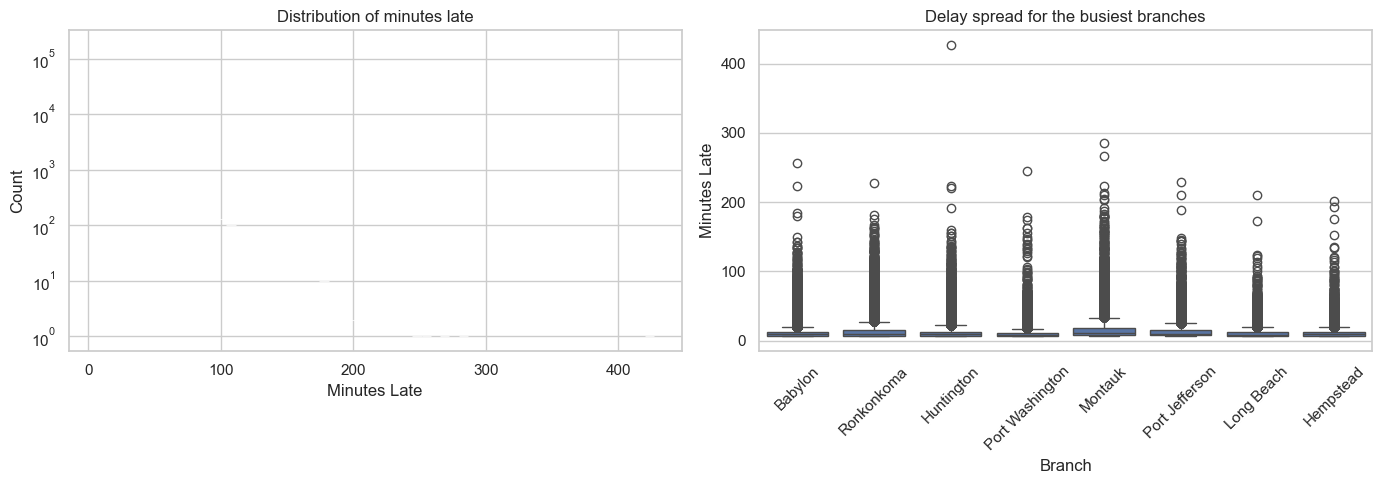

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=lirr_df,
    x='Minutes Late',
    bins=60,
    log_scale=(False, True),
    ax=axes[0],
    color='tab:blue',
)
axes[0].set_title('Distribution of minutes late')
axes[0].set_xlabel('Minutes Late')

branch_order = (
    lirr_df['Branch']
    .value_counts()
    .nlargest(8)
    .index
)
sns.boxplot(
    data=lirr_df[lirr_df['Branch'].isin(branch_order)],
    x='Branch',
    y='Minutes Late',
    order=branch_order,
    ax=axes[1],
)
axes[1].set_title('Delay spread for the busiest branches')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()


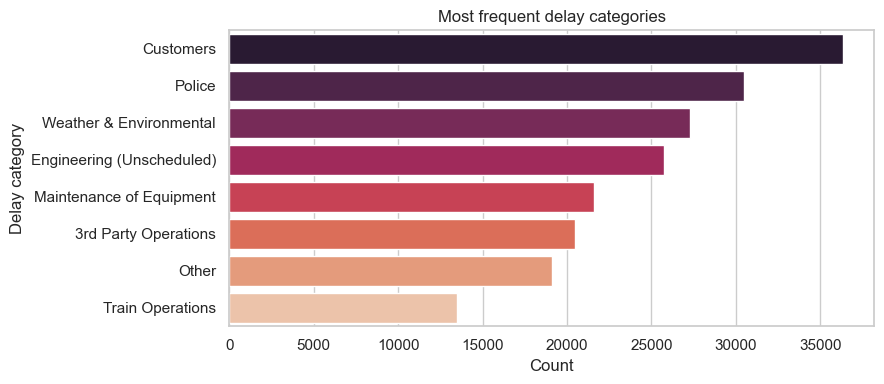

In [37]:
delay_category_counts = lirr_df['Delay Category'].value_counts().nlargest(8)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    x=delay_category_counts.values,
    y=delay_category_counts.index,
    hue=delay_category_counts.index,
    palette='rocket',
    ax=ax,
    legend=False,
)
ax.set_title('Most frequent delay categories')
ax.set_xlabel('Count')
ax.set_ylabel('Delay category')
plt.tight_layout()


## Temporal summaries (daily, weekday, monthly)
**Purpose:** capture day-to-day variability and longer-term patterns.
**How to read it:** weekday bars highlight routine schedule effects, while the monthly line plot shows seasonality or trend changes. Spikes in the monthly series can signal operational or weather-driven shifts.


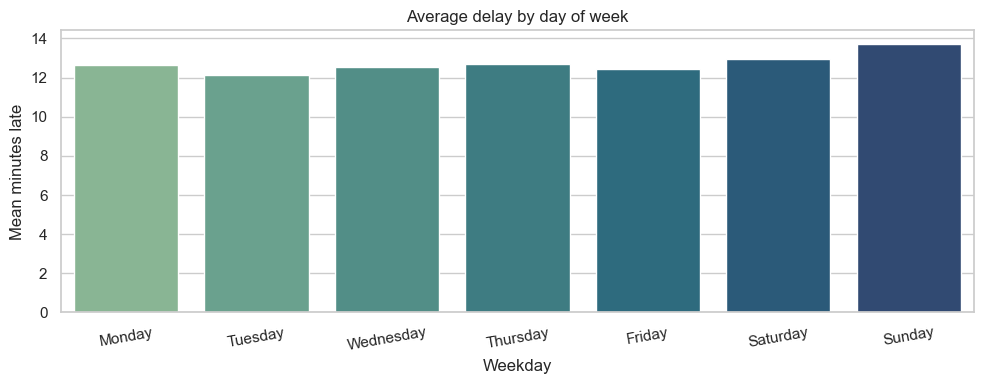

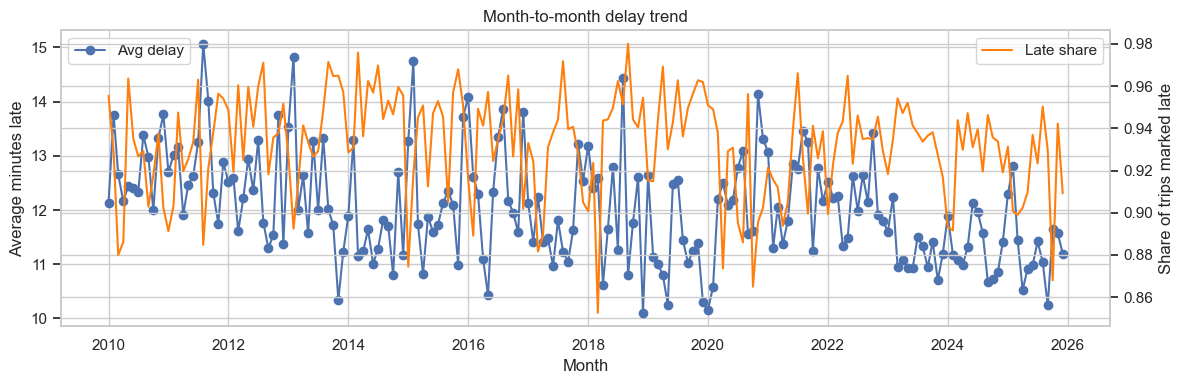

In [38]:
daily_summary = (
    lirr_df.groupby('date')
    .agg(
        total_trips=('Train', 'count'),
        avg_delay=('Minutes Late', 'mean'),
        median_delay=('Minutes Late', 'median'),
        late_trips=('is_late', 'sum'),
    )
    .assign(late_share=lambda df: df['late_trips'] / df['total_trips'])
)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_summary = (
    lirr_df.groupby('weekday')
    .agg(avg_delay=('Minutes Late', 'mean'), late_share=('is_late', 'mean'))
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=weekday_summary.reset_index(),
    x='weekday',
    y='avg_delay',
    hue='weekday',
    palette='crest',
    ax=ax,
    legend=False,
)
ax.set_title('Average delay by day of week')
ax.set_ylabel('Mean minutes late')
ax.set_xlabel('Weekday')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()

monthly_summary = (
    daily_summary
    .reset_index()
    .assign(month=lambda df: df['date'].dt.to_period('M'))
    .groupby('month')
    .agg(avg_delay=('avg_delay', 'mean'), late_share=('late_share', 'mean'))
    .reset_index()
)
monthly_summary['month_start'] = monthly_summary['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_summary['month_start'], monthly_summary['avg_delay'], label='Avg delay', marker='o')
ax.set_title('Month-to-month delay trend')
ax.set_ylabel('Average minutes late')
ax2 = ax.twinx()
ax2.plot(
    monthly_summary['month_start'],
    monthly_summary['late_share'],
    label='Late share',
    color='tab:orange',
)
ax2.set_ylabel('Share of trips marked late')
ax.set_xlabel('Month')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()


## Weather highlights
**Purpose:** summarize the seasonal weather patterns that may affect service.
**How to read it:** compare temperature curves with precipitation totals. Large precipitation peaks or extreme temperature ranges suggest months that could plausibly increase delays.


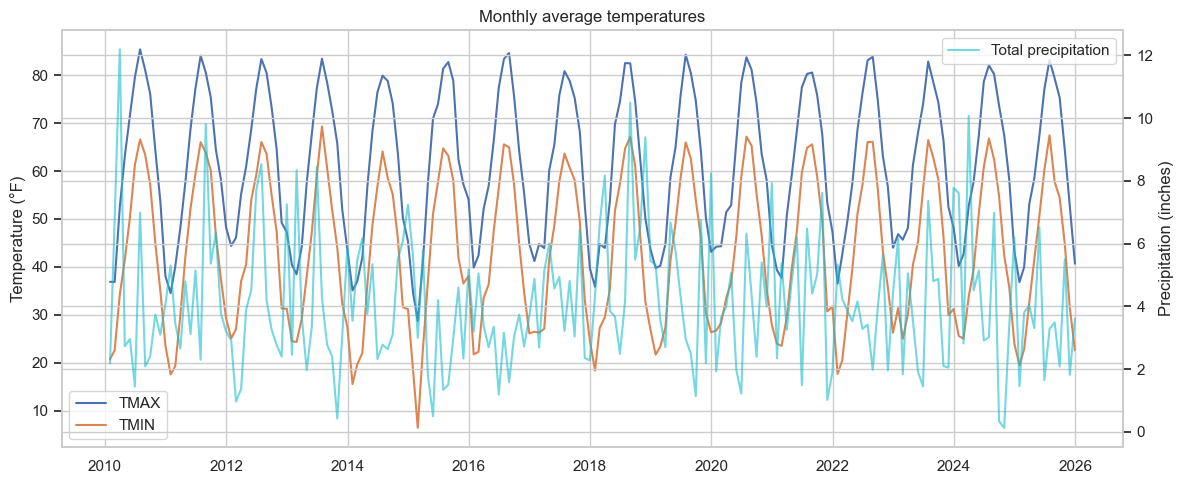

In [39]:
weather_monthly = (
    weather_df.set_index('DATE')
    .resample('ME')
    .agg(
        precipitation=('PRCP', 'sum'),
        tmax=('TMAX', 'mean'),
        tmin=('TMIN', 'mean'),
    )
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weather_monthly.index, weather_monthly['tmax'], label='TMAX')
ax.plot(weather_monthly.index, weather_monthly['tmin'], label='TMIN')
ax.set_title('Monthly average temperatures')
ax.set_ylabel('Temperature (°F)')
ax.legend()
ax2 = ax.twinx()
ax2.plot(
    weather_monthly.index,
    weather_monthly['precipitation'],
    label='Total precipitation',
    color='tab:cyan',
    alpha=0.6,
)
ax2.set_ylabel('Precipitation (inches)')
ax2.legend(loc='upper right')
plt.tight_layout()


## Weather vs. delay relationships
**Purpose:** test whether delays rise in tandem with weather severity.
**How to read it:** the correlation heatmap provides a quick directional check, while the precipitation vs. delay plot shows if heavier rain corresponds to higher average delays. Weak or noisy relationships here imply weather may be only one of several drivers.


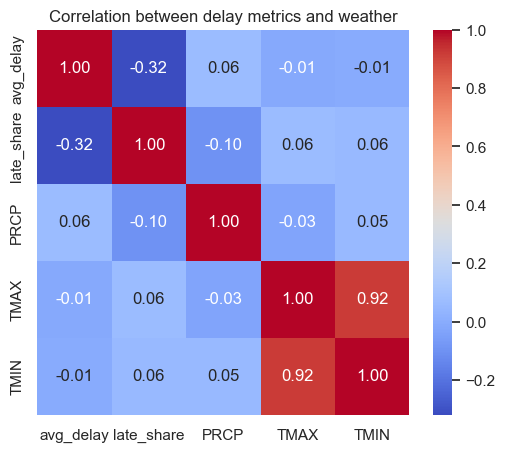

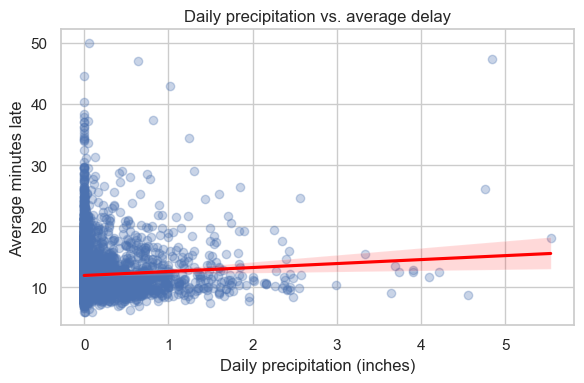

In [40]:
weather_daily = (
    weather_df.set_index('DATE')
    .resample('D')
    .agg(PRCP=('PRCP', 'sum'), TMAX=('TMAX', 'max'), TMIN=('TMIN', 'min'))
)

combined = (
    daily_summary
    .join(weather_daily, how='inner')
    .dropna(subset=['avg_delay', 'PRCP', 'TMAX', 'TMIN'])
)

corr = combined[['avg_delay', 'late_share', 'PRCP', 'TMAX', 'TMIN']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation between delay metrics and weather')

fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(
    data=combined,
    x='PRCP',
    y='avg_delay',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    ax=ax,
)
ax.set_title('Daily precipitation vs. average delay')
ax.set_xlabel('Daily precipitation (inches)')
ax.set_ylabel('Average minutes late')
plt.tight_layout()